# PHASE 6 — Machine Learning

15. Define the Prediction Target
- Already satisfied by `churned` (built in Phase 5) — a future-looking label defined entirely from the Oct-Dec outcome window, not "has already churned as of today."

16. Feature Engineering
- Potential features: tenure, monthly_charges, usage, usage_change, login_frequency, support_tickets, payment_failures, feature_count, satisfaction_score, engagement_trend, and days_since_last_login.
- NOTE: `enagement_change_pct` is excluded as a model feature — it was used to define `churned` itself, so including it would be circular, not predictive.

17. Train/Test Split
- Tool: scikit-learn.

18. Logistic Regression
- Build a baseline classification model and analyze predicted probabilities, coefficients, and classification threshold.

19. Random Forest
- Build a second model and compare it with Logistic Regression.

20. Evaluate the Models
- Use confusion matrix, precision, recall, F1, and ROC-AUC. Do not rely only on accuracy.
- Deliverable: 06_churn_modeling.ipynb

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

# Phase 6 - Machine Learning

# Objective: Predict churned using the features built and validated in Phase 5

In [150]:
## Load the feature table exported at the end of Phase 5

df = pd.read_csv("../data/phase6_modeling_data.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (48723, 59)
Columns: ['customer_id', 'age', 'gender', 'location', 'income_bracket', 'occupation', 'education_level', 'marital_status', 'household_size', 'acquisition_channel', 'customer_segment', 'savings_account', 'credit_card', 'personal_loan', 'investment_account', 'insurance_product', 'active_products', 'app_logins_frequency', 'feature_usage_diversity', 'bill_payment_user', 'auto_savings_enabled', 'credit_utilization_ratio', 'international_transactions', 'failed_transactions', 'tx_count', 'avg_tx_value', 'total_tx_volume', 'first_tx', 'last_tx', 'base_satisfaction', 'tx_satisfaction', 'product_satisfaction', 'satisfaction_score', 'nps_score', 'last_survey_date', 'support_tickets_count', 'resolved_tickets_ratio', 'app_store_rating', 'feedback_sentiment', 'feature_requests', 'complaint_topics', 'clv_segment', 'monthly_transaction_count', 'average_transaction_value', 'total_transaction_volume', 'transaction_frequency', 'last_transaction_date', 'preferred_transaction_type', 'fir

,customer_id,age,gender,location,income_bracket,occupation,education_level,marital_status,household_size,acquisition_channel,...,weekend_transaction_ratio,avg_daily_transactions,customer_tenure,churn_probability,customer_lifetime_value,churned,days_since_last_tnx,enagement_change_pct,avg_amount_change_pct,withdrawal_share_shift
0,93716481,44,Male,"Pereira, Risaralda",Very High,Engineer,Master,Married,5,Partnership,...,0.300000,0.030769,11.633333,0.362269,3.124148e+08,False,4,-0.136364,-0.452538,0.116650
1,49020929,44,Male,"Cali, Valle del Cauca",Medium,Construction Worker,Bachelor,Married,2,Paid Ad,...,0.181818,0.032934,11.500000,0.181790,1.670223e+08,False,37,-0.333333,-0.475427,-0.250000
2,52690950,45,Male,"Barranquilla, Atlántico",High,Construction Worker,Bachelor,Married,4,Paid Ad,...,0.300000,0.050000,8.766667,0.321265,1.940371e+07,False,16,0.000000,-0.318239,0.333333
3,23199751,45,Male,"Bogotá, Cundinamarca",High,Electrician,High School,Single,2,Referral,...,0.142857,0.047782,10.733333,0.336629,3.597811e+07,False,13,0.166667,-0.288743,-0.068627
4,61997066,44,Female,"Bogotá, Cundinamarca",Medium,Cleaner,Bachelor,Married,3,Paid Ad,...,0.315789,0.061889,11.633333,0.398151,3.046620e+08,False,33,-0.200000,-0.617676,-0.142857


In [151]:
## step 16 feature engineering
x = df[['days_since_last_tnx',
       'avg_amount_change_pct',
       'withdrawal_share_shift',
       'age', 'gender', 'income_bracket',
       'occupation', 'education_level', 'marital_status',
       'household_size', 'acquisition_channel', 'savings_account',
       'credit_card', 'personal_loan', 'investment_account','insurance_product',
       'satisfaction_score', 'support_tickets_count',
       'failed_transactions','app_logins_frequency']]
y = df['churned']

x.dtypes
X_encoded = pd.get_dummies(x, drop_first=True)

print(X_encoded)


       days_since_last_tnx  avg_amount_change_pct  withdrawal_share_shift  \
0                        4              -0.452538                0.116650   
1                       37              -0.475427               -0.250000   
2                       16              -0.318239                0.333333   
3                       13              -0.288743               -0.068627   
4                       33              -0.617676               -0.142857   
...                    ...                    ...                     ...   
48718                    0              -0.437306               -0.117647   
48719                   69              -0.124358               -0.125000   
48720                   28               0.038970                0.222222   
48721                   17              -0.638767               -0.125000   
48722                   65              -0.394353                0.000000   

       age  household_size  savings_account  credit_card  personal_loan  \


In [152]:
## item 17 train/test split - 80-20

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size = 0.2, random_state= 42, stratify = y
)
print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(38978, 62) (9745, 62)
0.21093950433577915 0.21087737301180093


In [153]:
## item 18 Logistic Regression 
## Scale the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # learn mean/std from TRAIN only
X_test_scaled = scaler.transform(X_test)  # apply the samw mean/std to test

## Fit the model

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)     


print("Train accuracy:", log_reg.score(X_train_scaled, y_train))
print("Test accuracy:", log_reg.score(X_test_scaled, y_test))

Train accuracy: 0.7890604956642209
Test accuracy: 0.7891226269881991


/Users/hieule/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hieule/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hieule/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hieule/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/hieule/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_

count    9745.000000
mean        0.210959
std         0.029710
min         0.048145
25%         0.193136
50%         0.211071
75%         0.229339
max         0.337187
dtype: float64
ROC-AUC: 0.5742527819173003


/Users/hieule/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hieule/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hieule/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


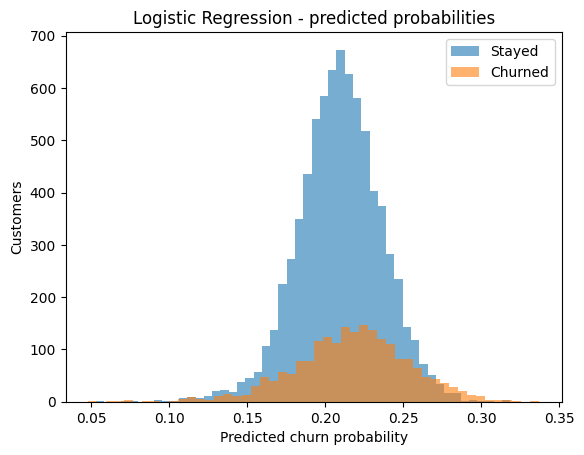

In [154]:
# predicted probabilities

y_prob = log_reg.predict_proba(X_test_scaled)[:,1]  # column 1 = P(churned=1)

print(pd.Series(y_prob).describe())
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

plt.hist(y_prob[y_test == 0], bins=50, alpha=0.6, label="Stayed")
plt.hist(y_prob[y_test == 1], bins=50, alpha=0.6, label="Churned")
plt.xlabel("Predicted churn probability"); plt.ylabel("Customers")
plt.legend(); plt.title("Logistic Regression - predicted probabilities")
plt.show()

In [155]:
# Coefficient (What drives churn)

coefs = pd.DataFrame({
    "feature": X_encoded.columns,        # ← comma added
    "coef": log_reg.coef_[0]
})
coefs["odds_ratio"] = np.exp(coefs["coef"])   # ← lowercase "coef"
coefs = coefs.reindex(coefs["coef"].abs().sort_values(ascending=False).index)

coefs.head(20)


,feature,coef,odds_ratio
1,avg_amount_change_pct,-0.163373,0.849274
10,satisfaction_score,-0.042232,0.958648
2,withdrawal_share_shift,-0.031482,0.969008
46,occupation_Psychologist,0.030129,1.030587
48,occupation_Salesperson,-0.028750,0.971659
21,occupation_Bank Teller,0.024699,1.025006
0,days_since_last_tnx,0.024242,1.024538
59,acquisition_channel_Paid Ad,0.024161,1.024456
30,occupation_Electrician,-0.023073,0.977191
57,marital_status_Single,0.022093,1.022339


In [156]:
## Classification threshold

for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_prob >= t).astype(int)
    print(f"threshold={t:.1f}  "
          f"precision={precision_score(y_test, y_pred_t):.3f}  "
          f"recall={recall_score(y_test, y_pred_t):.3f}  "
          f"f1={f1_score(y_test, y_pred_t):.3f}  "
          f"flagged={y_pred_t.mean():.1%}")


threshold=0.2  precision=0.223  recall=0.700  f1=0.339  flagged=66.1%
threshold=0.3  precision=0.783  recall=0.009  f1=0.017  flagged=0.2%
threshold=0.4  precision=0.000  recall=0.000  f1=0.000  flagged=0.0%
threshold=0.5  precision=0.000  recall=0.000  f1=0.000  flagged=0.0%


/Users/hieule/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/hieule/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [157]:
## Item 19: Random Forest

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Train accuracy:", rf.score(X_train, y_train))
print("Test accuracy:", rf.score(X_test, y_test))

Train accuracy: 1.0
Test accuracy: 0.8193945613134941


count    9745.000000
mean        0.214973
std         0.141866
min         0.003333
25%         0.123333
50%         0.190000
75%         0.266667
max         0.956667
dtype: float64
ROC-AUC (Random Forest):    0.7605547065579527
ROc-AUC (Logistic Regression):      0.5742527819173003


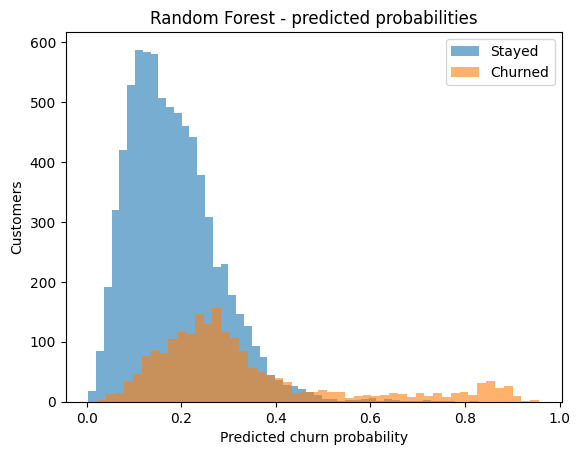

In [158]:
# Probabilities and ROC - AUC
y_prob_rf = rf.predict_proba(X_test)[:,1]

print(pd.Series(y_prob_rf).describe())
print("ROC-AUC (Random Forest):   ", roc_auc_score(y_test, y_prob_rf))
print("ROc-AUC (Logistic Regression):     ", roc_auc_score(y_test, y_prob))


plt.hist(y_prob_rf[y_test ==0], bins=50, alpha=0.6, label="Stayed")
plt.hist(y_prob_rf[y_test ==1], bins=50, alpha=0.6, label="Churned")
plt.xlabel("Predicted churn probability"); plt.ylabel("Customers")
plt.legend(); plt.title("Random Forest - predicted probabilities")
plt.show()
      

avg_amount_change_pct           0.181285
withdrawal_share_shift          0.149274
days_since_last_tnx             0.080923
app_logins_frequency            0.062582
household_size                  0.047815
age                             0.042239
support_tickets_count           0.034134
satisfaction_score              0.021675
gender_Male                     0.017105
investment_account              0.016473
credit_card                     0.015584
personal_loan                   0.015570
education_level_High School     0.015026
failed_transactions             0.014997
acquisition_channel_Referral    0.014768
income_bracket_Medium           0.014120
insurance_product               0.013396
savings_account                 0.012155
acquisition_channel_Paid Ad     0.011835
income_bracket_Low              0.011323
dtype: float64


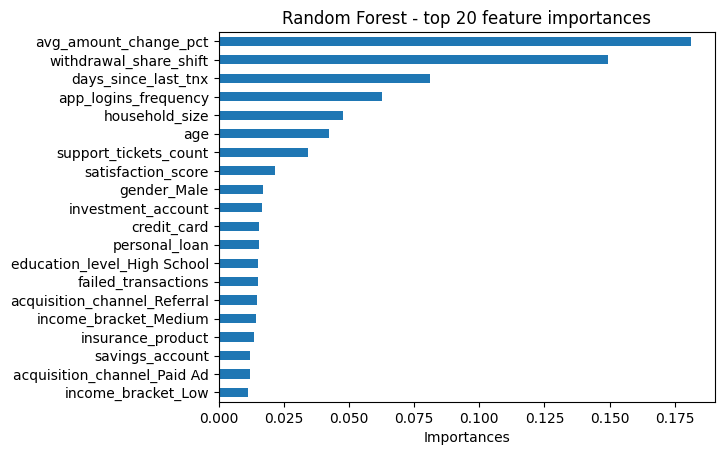

In [159]:
# Feature Importance:nwhat the forest relies on

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(20))


importances.head(20).sort_values().plot(kind="barh")
plt.title("Random Forest - top 20 feature importances")
plt.xlabel("Importances")
plt.show()

In [160]:
# Threshold Check

for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_prob_rf >= t).astype(int)
    print(f"threshold={t:.1f}   "
          f"precision= {precision_score(y_test, y_pred_t):.3f}  "
          f"recall={recall_score(y_test, y_pred_t):.3f}  "
          f"f1={f1_score(y_test, y_pred_t):.3f}  "
          f"flagged={y_pred_t.mean():.1%}")

threshold=0.2   precision= 0.342  recall=0.759  f1=0.472  flagged=46.8%
threshold=0.3   precision= 0.495  recall=0.408  f1=0.447  flagged=17.4%
threshold=0.4   precision= 0.709  recall=0.229  f1=0.346  flagged=6.8%
threshold=0.5   precision= 0.871  recall=0.171  f1=0.286  flagged=4.1%


### Item 19 Summary — Random Forest vs. Logistic Regression

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Test accuracy | 0.789 | **0.819** |
| ROC-AUC | 0.574 | **0.761** |
| Spread of predicted probabilities (std) | 0.030 | **0.142** |

**Key findings**

- **Random Forest clearly outperforms the baseline.** Logistic Regression's accuracy (0.789) equals a naive "no one churns" prediction, and its AUC (0.57) is barely above random. Random Forest reaches an AUC of 0.76: it ranks a real churner above a non-churner 76% of the time.

- **Churn is non-linear.** Both models used the same features, so the gap comes from the model type. Churn risk depends on thresholds and combinations of behaviors, which trees can capture and a linear model cannot.

- **Behavior drives churn, not demographics.** The top four features are all behavioral: `avg_amount_change_pct` (0.18), `withdrawal_share_shift` (0.15), `days_since_last_tnx` (0.08) and `app_logins_frequency` (0.06). Together they account for ~47% of total importance. Demographic and product-ownership features each contribute under 2%.

- **Overfitting check.** Train accuracy is 1.0 because fully grown trees memorize the training data. Test AUC (0.76) confirms the model still generalizes to unseen customers. Limiting tree depth removed the overfitting but did not improve test AUC.

**Threshold choice**

| Threshold | Precision | Recall | Customers flagged |
|---|---|---|---|
| 0.2 | 0.34 | 0.76 | 46.8% |
| **0.3** | **0.50** | **0.41** | **17.4%** |
| 0.4 | 0.71 | 0.23 | 6.8% |
| 0.5 | 0.87 | 0.17 | 4.1% |

I select **0.3** as the working threshold. It flags 17% of customers, and half of them actually churn, which is 2.3× better than the 21% base rate. It catches 41% of all churners, and its F1 (0.45) is close to the best (0.47) with a list one-third the size. The default 0.5 is too strict for early warning because it misses 83% of churners. The final threshold should depend on the retention team's capacity and the cost of a retention offer versus a lost customer.


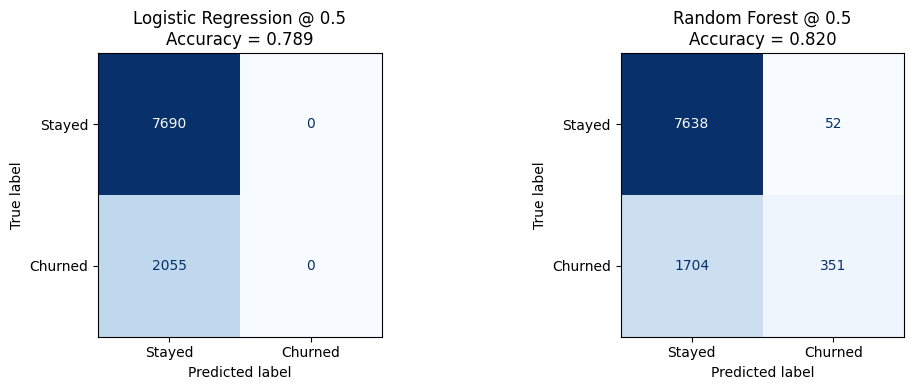

In [161]:
# Evaluation the models

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

# default 0.5 threhols: why accuracy alone is misleading

fig, axes = plt.subplots(1,2, figsize=(11, 4))

for ax, name, probs in [(axes[0], "Logistic Regression", y_prob),
                        (axes[1], "Random Forest", y_prob_rf)]:
    y_prob_default = (probs >= 0.5).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_prob_default,
        display_labels=["Stayed","Churned"],
        cmap="Blues", values_format="d", ax=ax, colorbar=False
    )
    acc = accuracy_score(y_test, y_prob_default)
    ax.set_title(f"{name} @ 0.5\nAccuracy = {acc:.3f}")

plt.tight_layout()
plt.show()

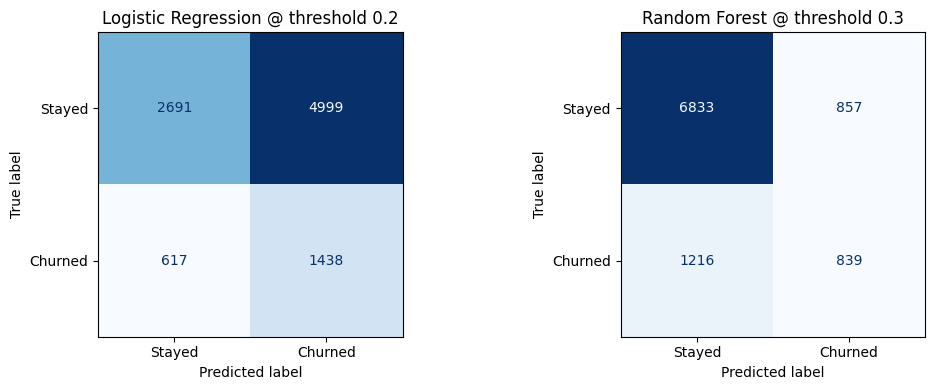

In [162]:
# Confusion matrices at each model's chosen threhold

thresholds = {"Logistic Regression": 0.2, "Random Forest": 0.3}
probs_dict = {"Logistic Regression": y_prob, "Random Forest": y_prob_rf}

fig, axes = plt.subplots(1,2, figsize=(11,4))

for ax, name in zip(axes, thresholds):
    t = thresholds[name]
    y_pred = (probs_dict[name] >= t).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Stayed", "Churned"],
        cmap="Blues", values_format="d", ax=ax, colorbar=False
    )
    ax.set_title(f"{name} @ threshold {t}")

plt.tight_layout()
plt.show()

In [163]:
# classification reports

for name in thresholds:
    t = thresholds[name]
    y_pred = (probs_dict[name] >= t).astype(int)
    print(f"==== {name} @ threshold {t} ====")
    print(classification_report(y_test, y_pred,
                                target_names=["Stayed", "Churned"], digits=3))

==== Logistic Regression @ threshold 0.2 ====
              precision    recall  f1-score   support

      Stayed      0.813     0.350     0.489      7690
     Churned      0.223     0.700     0.339      2055

    accuracy                          0.424      9745
   macro avg      0.518     0.525     0.414      9745
weighted avg      0.689     0.424     0.458      9745

==== Random Forest @ threshold 0.3 ====
              precision    recall  f1-score   support

      Stayed      0.849     0.889     0.868      7690
     Churned      0.495     0.408     0.447      2055

    accuracy                          0.787      9745
   macro avg      0.672     0.648     0.658      9745
weighted avg      0.774     0.787     0.780      9745



In [164]:
# A side by side comparison table

rows = []
for name in thresholds:
    t = thresholds[name]
    probs = probs_dict[name]
    y_pred = (probs >= t).astype(int)
    rows.append({
        "Model": name,
        "Thresholds": t,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, probs),
        "Flagged %": y_pred.mean()
    })

comparision = pd.DataFrame(rows).set_index("Model").round(3)
comparision

,Thresholds,Accuracy,Precision,Recall,F1,ROC-AUC,Flagged %
Model,,,,,,,
Logistic Regression,0.2,0.424,0.223,0.700,0.339,0.574,0.661
Random Forest,0.3,0.787,0.495,0.408,0.447,0.761,0.174


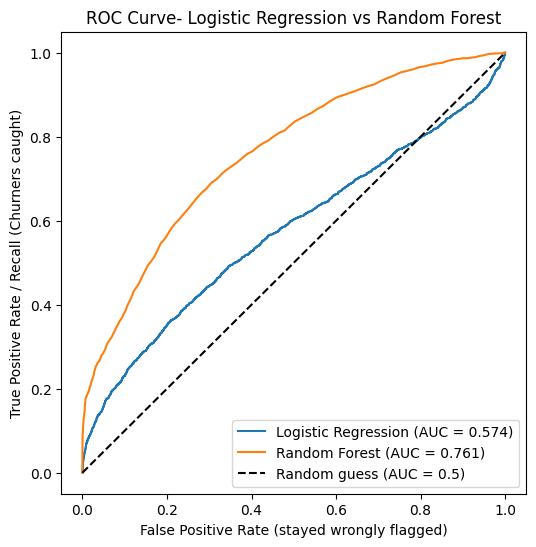

In [165]:
# ROC curves for both models on one chart

plt.figure(figsize=(6,6))

for name, probs in probs_dict.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")


plt.plot([0, 1], [0,1], "k--", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate (stayed wrongly flagged)")
plt.ylabel("True Positive Rate / Recall (Churners caught)")
plt.title("ROC Curve- Logistic Regression vs Random Forest")
plt.legend(loc="lower right")
plt.show()

### Item 20 Summary — Model Evaluation

**1. Why accuracy alone is misleading**

At sklearn's default 0.5 threshold, Logistic Regression predicts "stay" for every customer. It catches **0 of 2,055 churners** yet still scores **78.9% accuracy**, because 78.9% of customers do not churn. In both models, the more useful early-warning setting has *lower* accuracy. Models are therefore judged on precision, recall, F1 and ROC-AUC.

**2. Final comparison (each model at its chosen threshold)**

| Model | Threshold | Accuracy | Precision | Recall | F1 | ROC-AUC | Customers flagged |
|---|---|---|---|---|---|---|---|
| Logistic Regression | 0.2 | 0.424 | 0.223 | **0.700** | 0.339 | 0.574 | 66.1% |
| **Random Forest** | **0.3** | **0.787** | **0.495** | 0.408 | **0.447** | **0.761** | **17.4%** |

Random Forest wins on 5 of 6 metrics. Logistic Regression's higher recall comes from flagging two-thirds of all customers, and its precision (0.22) is barely above the 21% base rate, so its alerts carry little information.

**3. What the confusion matrices mean for a retention team**

| | Logistic Regression @ 0.2 | Random Forest @ 0.3 |
|---|---|---|
| Customers to contact | 6,437 | **1,696** |
| Real churners reached | 1,438 | 839 |
| Wasted contacts (false alarms) | 4,999 | **857** |
| Contacts per churner found | ~4.5 | **~2** |

Random Forest produces a list about 4× shorter, and half of the customers on it actually churn.

**4. ROC curve**

The Random Forest curve lies above the Logistic Regression curve at **every** threshold, while Logistic Regression stays close to the random-guess diagonal. The Random Forest's advantage therefore does not depend on the specific threshold chosen. For example, at a 20% false-positive rate, Random Forest catches ~58% of churners versus ~35% for Logistic Regression.

**5. Conclusion**

- **Selected model:** Random Forest with a **0.3 threshold**.
- **Business value:** it flags 17% of customers, and 50% of them are real churners, 2.3× better than random targeting.
- **Limitation:** it misses 59% of churners (1,216 customers), who show no clear warning signs in the current behavioral features. Additional signals, such as support interactions or competitor activity, could help close this gap.
- **Next step (Phase 7):** use the Random Forest's predicted probabilities as each customer's churn risk score and group customers into risk tiers.
